In [129]:
import pandas as pd

In [130]:
bike_day = pd.read_csv("../Data/서울특별시 공공자전거 이용정보(시간대별)_202512.csv", encoding="cp949")

In [131]:
bike_eunpeong = pd.read_csv("../Data/eun_2024_data.csv")
bike_eunpeong

,Unnamed: 0,기준_날짜,집계_기준,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,기준_시간
0,0,20240101,출발시간,ST-2470,불광1동_053_1,ST-180,무악동_001_1,3.0,194.0,16933.0,1430.0
1,1,20240101,도착시간,ST-2775,응암1동_033_1,ST-2775,응암1동_033_1,1.0,0.0,0.0,1550.0
2,2,20240101,도착시간,ST-453,진관동_038_9,ST-2241,진관동_080_1,1.0,11.0,1764.0,1550.0
3,3,20240101,도착시간,ST-459,녹번동_033_1,ST-467,녹번동_001_3,1.0,6.0,1150.0,1550.0
4,4,20240101,도착시간,ST-461,응암1동_032_2,ST-461,응암1동_032_2,1.0,0.0,0.0,1550.0
...,...,...,...,...,...,...,...,...,...,...,...
1997928,1997928,20241231,도착시간,ST-460,응암3동_007_1,ST-459,녹번동_043_1,1.0,13.0,3590.0,1635.0
1997929,1997929,20241231,도착시간,ST-460,응암3동_007_1,ST-481,구산동_029_1,1.0,15.0,2772.0,150.0
1997930,1997930,20241231,도착시간,ST-461,응암1동_023_2,ST-460,응암3동_007_1,1.0,14.0,1651.0,2150.0
1997931,1997931,20241231,도착시간,ST-2264,역촌동_068_1,ST-461,응암1동_023_2,1.0,NaN,NaN,2145.0


In [132]:
bike_eunpeong[bike_eunpeong.전체_이용_분.isna()]

,Unnamed: 0,기준_날짜,집계_기준,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,기준_시간
794185,794185,20240601,도착시간,ST-2250,녹번동_021_1,ST-1029,녹번동_041_1,1.0,NaN,NaN,1545.0
794191,794191,20240601,출발시간,ST-461,응암1동_032_2,ST-455,응암1동_032_1,1.0,NaN,NaN,1545.0
794206,794206,20240601,출발시간,ST-467,녹번동_001_3,ST-467,녹번동_001_3,1.0,NaN,NaN,1550.0
794225,794225,20240601,도착시간,ST-481,구산동_062_1,ST-481,구산동_062_1,1.0,NaN,NaN,1545.0
794230,794230,20240601,출발시간,ST-481,구산동_062_1,ST-481,구산동_062_1,1.0,NaN,NaN,1540.0
...,...,...,...,...,...,...,...,...,...,...,...
1997679,1997679,20241231,도착시간,ST-2252,신사1동_032_1,ST-2252,신사1동_032_1,1.0,NaN,NaN,1545.0
1997755,1997755,20241231,도착시간,ST-460,응암3동_007_1,ST-462,응암3동_002_2,1.0,NaN,NaN,1140.0
1997781,1997781,20241231,도착시간,ST-1482,불광1동_018_1,ST-473,불광1동_018_3,1.0,NaN,NaN,50.0
1997919,1997919,20241231,도착시간,ST-467,녹번동_048_3,ST-2470,불광1동_018_2,1.0,NaN,NaN,1435.0


In [133]:
bike_eunpeong.전체_이용_분.isna().sum()

np.int64(29803)

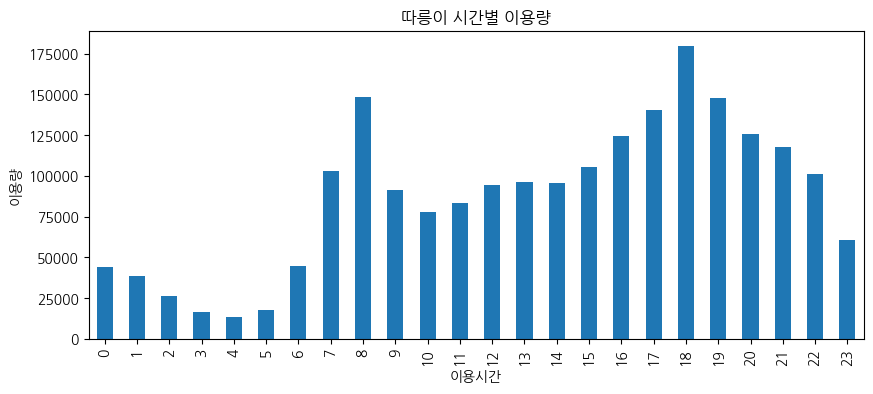

In [134]:
# 이용시간별 시각화
import koreanize_matplotlib
import matplotlib.pyplot as plt

bike_eunpeong = bike_eunpeong.rename(columns={"기준_시간":"time"})

bike_eunpeong["hour"] = (bike_eunpeong["time"] // 100).astype(int)

hourly = bike_eunpeong.groupby("hour")["전체_건수"].sum()

hourly.plot(kind="bar", figsize=(10,4))

plt.xlabel("이용시간")
plt.ylabel("이용량")
plt.title("따릉이 시간별 이용량")
plt.show()

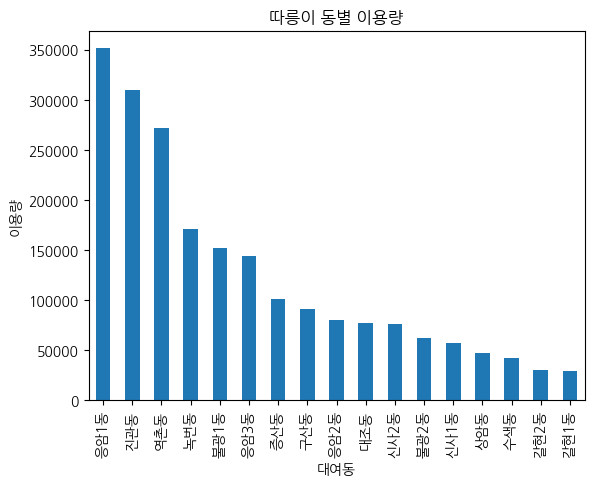

In [135]:
# 동별 이용량 시각화
bike_eunpeong["start_dong"] = bike_eunpeong["시작_대여소명"].str.split("_").str[0]

dong_usage = bike_eunpeong.groupby("start_dong")["전체_건수"].sum()

dong_usage.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("대여동")
plt.ylabel("이용량")
plt.title("따릉이 동별 이용량")
plt.show()


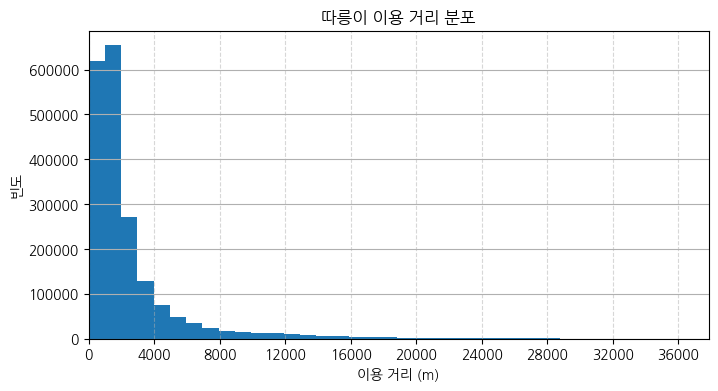

In [136]:
# 이용 거리 분포
import numpy as np

plt.figure(figsize=(8,4))

bike_eunpeong["전체_이용_거리"].hist(bins=400)

# 과학표기 제거
plt.ticklabel_format(style='plain', axis='both')

# x축 범위
xmax = bike_eunpeong["전체_이용_거리"].quantile(0.9995)
plt.xlim(0, xmax)

# x축 tick 간격 지정
plt.xticks(np.arange(0, xmax, 4000))

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xlabel("이용 거리 (m)")
plt.ylabel("빈도")
plt.title("따릉이 이용 거리 분포")

plt.show()

----
#### 은평구 학교 데이터 수집

In [137]:
school = pd.read_csv("../Data/서울시 은평구 집단급식소 인허가 정보.csv", encoding="euc-kr")

In [138]:
# 학교 데이터만 남기기
school = school[school.사업장명.str.contains("초등학교") | school.사업장명.str.contains("중학교") | 
       school.사업장명.str.contains("고등학교") | school.사업장명.str.contains("대학")
       ][['사업장명','좌표정보(X)','좌표정보(Y)','도로명주소']]

In [139]:
from pyproj import Transformer

# 중부원점 TM → WGS84
transformer = Transformer.from_crs("EPSG:5181", "EPSG:4326", always_xy=True)

lon, lat = transformer.transform(
    school["좌표정보(X)"].values,
    school["좌표정보(Y)"].values
)

school["lon"] = lon
school["lat"] = lat

In [140]:
school[school['좌표정보(Y)'].isna()]
# 위도: 37.5905122161631 경도: 126.925112608529
# 위도: 37.5887531914177 경도: 126.921616096958
# 위도: 37.5846402882465 경도: 126.921809482886 / 서울특별시 은평구 가좌로5길 5 (응암동)
# 위도: 37.6329931167171 경도: 126.930713128967
# 위도: 37.6426828611882 경도: 126.918730453447

,사업장명,좌표정보(X),좌표정보(Y),도로명주소,lon,lat
44,서울연은초등학교,NaN,NaN,"서울특별시 은평구 백련산로2길 35, 2층 (응암동)",NaN,NaN
48,서울응암초등학교,NaN,NaN,서울특별시 은평구 가좌로6길 20 (응암동),NaN,NaN
175,충암중학교,NaN,NaN,NaN,NaN,NaN
203,신도중학교,NaN,NaN,"서울특별시 은평구 진관1로 77-30 (진관동,지상1층)",NaN,NaN
217,은빛초등학교,NaN,NaN,서울특별시 은평구 진관3로 73-17 (진관동),NaN,NaN


In [141]:
school.loc[44, ['lat','lon']] = [37.5905122161631,126.925112608529]
school.loc[48, ['lat','lon']] = [37.5887531914177,126.921616096958]
school.loc[203,['lat','lon']] = [37.6329931167171,126.930713128967]
school.loc[217,['lat','lon']] = [37.6426828611882,126.918730453447]
school.loc[175, ['도로명주소','lat','lon']] = [
    '서울특별시 은평구 가좌로5길 5 (응암동)',
    37.5846402882465,
    126.921809482886
]

In [142]:
school = school[['사업장명','lat','lon','도로명주소']]
school.to_csv("../Data/은평구_학교 정보.csv", index=False)

In [143]:
import folium
import requests

school_layer = folium.FeatureGroup(name="학교", show=True)

for _, row in school.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=2,              # 점 크기
        popup=row['사업장명'],
        color='blue',
        fill=True,
        fill_opacity=0.7
    ).add_to(school_layer)

# 서울 구 경계 GeoJSON
url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
geo = requests.get(url).json()

# 은평구만 필터
eunpyeong_geojson = {
    "type": "FeatureCollection",
    "features": [f for f in geo["features"] if f["properties"]["name"] == "은평구"]
}

boundary_layer = folium.GeoJson(
    eunpyeong_geojson,
    name="은평구 경계",
    style_function=lambda x: {
        "fillColor": "none",
        "color": "black",
        "weight": 3
    }
)



---------
#### 은평구 공동주택 데이터 수집

In [144]:
house = pd.read_csv("../Data/서울특별시_은평구_공동주택 현황_20250904.csv", encoding="euc-kr")

In [145]:
house

,단지명,소재지도로명주소,동수,최고층수,세대수,사용검사일,전화번호,팩스번호,구분
0,미성아파트,증산로15길 35-10,5,15,570,1987-11-27,306-7429,6383-7430,의무관리공동주택(APT)
1,신성아파트,증산로15길 67-7,2,13,238,1988-06-30,305-9810,309-8085,의무관리공동주택(APT)
2,응암우성아파트,가좌로7나길 30,4,15,292,1988-07-01,305-5337,304-0820,의무관리공동주택(APT)
3,미성아파트,통일로 780,10,15,"1,340",1988-10-30,383-8570,383-8572,의무관리공동주택(APT)
4,경향파크아파트,갈현로15길 53,2,15,171,1989-11-10,358-7823,358-7707,의무관리공동주택(APT)
...,...,...,...,...,...,...,...,...,...
202,백련산 힐스테이트 3차,백련산로2길 46,1,15,219,2011-12-22,3151-0411,3151-0412,공공임대주택(SH공사 관리)
203,은평뉴타운 구파발 10단지 제3,북한산로 2,9,15,712,2012-02-23,385-6891,385-6892,공공임대주택(SH공사 관리)
204,불광롯데캐슬,불광로2길 27,1,10,100,2018-11-29,357-0909,357-0919,공공임대주택(SH공사 관리)
205,은평뉴타운 은뜨락(리츠1호),통일로 972,3,15,350,2019-02-08,070-7335-3765,357-2225,공공임대주택(SH공사 관리)


In [146]:
import requests
import pandas as pd

KAKAO_API_KEY = "ce6890c895245a8414a421c6bdface99"

def geocode(address):
    
    if pd.isna(address):
        return None, None
    
    url = "https://dapi.kakao.com/v2/local/search/address.json"
    
    headers = {
        "Authorization": f"KakaoAK {KAKAO_API_KEY}"
    }
    
    params = {
        "query": address
    }

    res = requests.get(url, headers=headers, params=params)
    result = res.json()

    if 'documents' in result and len(result['documents']) > 0:
        lon = result['documents'][0]['x']
        lat = result['documents'][0]['y']
        return float(lat), float(lon)
    else:
        return None, None

house['주소_full'] = '서울특별시 은평구 ' + house['소재지도로명주소']
house[['lat','lon']] = house['주소_full'].apply(
    lambda x: pd.Series(geocode(x))
)

In [147]:
house = house[['단지명','소재지도로명주소','세대수','lat','lon']]
house

,단지명,소재지도로명주소,세대수,lat,lon
0,미성아파트,증산로15길 35-10,570,37.589515,126.907740
1,신성아파트,증산로15길 67-7,238,37.590194,126.905697
2,응암우성아파트,가좌로7나길 30,292,37.584009,126.918939
3,미성아파트,통일로 780,"1,340",37.615862,126.928433
4,경향파크아파트,갈현로15길 53,171,37.610994,126.905584
...,...,...,...,...,...
202,백련산 힐스테이트 3차,백련산로2길 46,219,37.589005,126.924736
203,은평뉴타운 구파발 10단지 제3,북한산로 2,712,37.642243,126.916236
204,불광롯데캐슬,불광로2길 27,100,37.612828,126.934314
205,은평뉴타운 은뜨락(리츠1호),통일로 972,350,37.630176,126.919916


In [148]:
house[house.lat.isna()]
# 위도: 37.6117053317588 경도: 126.936851789105
# 37.583158, 126.899374
# 37.5833367,126.8992638
# 37.6021379498557,126.907768732907
# 37.601486974668,126.906610607425

,단지명,소재지도로명주소,세대수,lat,lon
66,북한산래미안아파트,"진흥로 265,267",647,NaN,NaN
102,수정,은평터널로2길 21,66,NaN,NaN
181,은평타운,은평터널로2길 15,30,NaN,NaN
185,무진,"갈현로3가길 16,15",81,NaN,NaN
186,성락,"갈현로3나길 10,11",96,NaN,NaN


In [149]:
house.loc[66,  ['lat','lon']] = [37.6117053317588, 126.936851789105]
house.loc[102, ['lat','lon']] = [37.583158, 126.899374]
house.loc[181, ['lat','lon']] = [37.5833367, 126.8992638]
house.loc[185, ['lat','lon']] = [37.6021379498557, 126.907768732907]
house.loc[186, ['lat','lon']] = [37.601486974668, 126.906610607425]

In [150]:
house[house.lat.isna()]


,단지명,소재지도로명주소,세대수,lat,lon


In [151]:
house = house[['단지명','소재지도로명주소','세대수','lat','lon']]
house.to_csv("../Data/은평구_공동주택 정보.csv", index=False)

In [152]:
import folium

house_layer = folium.FeatureGroup(name="공동주택", show=True)

for _, row in house.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=2,              # 점 크기
        popup=row['단지명'],
        color='red',
        fill=True,
        fill_opacity=0.7
    ).add_to(house_layer)



-----
#### 은평구 공원 데이터 수집

In [153]:
park = pd.read_csv("../Data/서울시 주요 공원현황.csv", encoding="euc-kr")
park = park[['공원명', '면적', '지역', 'X좌표(WGS84)', 'Y좌표(WGS84)']]
park = park[park.지역 == '은평구']

In [154]:
park.to_csv("../Data/은평구_공원 정보.csv", index=False)

In [155]:
import folium

park_layer = folium.FeatureGroup(name="공원", show=True)

for _, row in park.iterrows():
    folium.CircleMarker(
        location=[row['Y좌표(WGS84)'], row['X좌표(WGS84)']],
        radius=2,              # 점 크기
        popup=row['공원명'],
        color='green',
        fill=True,
        fill_opacity=0.7
    ).add_to(park_layer)



-----
#### 은평구 따릉이 대여소 위치

In [156]:
bike_stop = pd.read_csv("../Data/은평구99개_staion.csv")
bike_stop

,Unnamed: 0,대여소_ID,주소1,주소2,위도,경도
0,76,ST-93,서울특별시 은평구 수색로 지하175,디지털미디어시티역 2번출구 앞,37.575069,126.899918
1,572,ST-481,서울특별시 은평구 서오릉로 163,LG서비스 역촌점,37.612484,126.914879
2,573,ST-480,서울특별시 은평구 연서로 117,예일여중,37.610004,126.916397
3,575,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
4,576,ST-478,서울특별시 은평구 역촌동 41-7,구 서부경찰서 건너편,37.601662,126.920303
...,...,...,...,...,...,...
94,3380,ST-1027,서울특별시 은평구 진관동 141-27,은평뉴타운 도서관,37.637222,126.933304
95,3381,ST-1025,서울특별시 은평구 응암동 82-31,은평구청 교차로,37.601700,126.927422
96,3382,ST-1024,서울특별시 은평구 진관동 44-28,금암 문화공원,37.644684,126.918457
97,3383,ST-1023,서울특별시 은평구 진관동 30-23,상림마을 롯데캐슬2단지 옆,37.645851,126.923798


In [157]:
import folium

bike_stop_layer = folium.FeatureGroup(name="따릉이 대여소", show=True)

for _, row in bike_stop.iterrows():
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=2,              # 점 크기
        popup=row['주소2'],
        color='yellow',
        fill=True,
        fill_opacity=0.7
    ).add_to(bike_stop_layer)



----
#### 버스 정류장 데이터 표시

In [158]:
bus_stop = pd.read_csv("../Data/202401_bus_jan.csv")

In [159]:
bus_stop

,Unnamed: 0,버스정류장ARS번호,승차총승객수,하차총승객수,X,Y
0,0,12103,1874,10259,37.610088,126.930460
1,1,12104,3311,5251,37.612484,126.928389
2,2,12105,711,5442,37.616295,126.924228
3,3,12106,28599,26725,37.618193,126.922162
4,4,12107,1393,1829,37.622791,126.919943
...,...,...,...,...,...,...
287,287,12479,2458,210,37.634433,126.932132
288,288,12480,3451,6691,37.623466,126.918393
289,289,12481,5711,3965,37.623284,126.918970
290,290,12498,5854,2287,37.600189,126.904511


In [160]:
import folium

bus_stop_layer = folium.FeatureGroup(name="버스 정류장", show=True)

for _, row in bus_stop.iterrows():
    folium.CircleMarker(
        location=[row['X'], row['Y']],
        radius=2,              # 점 크기
        popup=row['버스정류장ARS번호'],
        color='purple',
        fill=True,
        fill_opacity=0.7
    ).add_to(bus_stop_layer)



----
#### 지하철 데이터 표시

In [161]:
subway_stop = pd.read_csv("../Data/subway_24_ll.csv")

In [162]:
subway_stop

,역명,위도,경도
0,구산,37.611377,126.917270
1,구파발,37.636763,126.918821
2,녹번,37.600927,126.935756
3,독바위,37.618456,126.933031
4,디지털미디어시티,37.576958,126.898609
5,불광,37.610873,126.929390
6,연신내,37.618780,126.921300
7,응암,37.598605,126.915577


In [163]:
import folium

subway_layer = folium.FeatureGroup(name="지하철", show=True)

for _, row in subway_stop.iterrows():
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=2,              # 점 크기
        popup=row['역명'],
        color='black',
        fill=True,
        fill_opacity=0.7
    ).add_to(subway_layer)



In [164]:
import folium

m = folium.Map(
    location=[37.6176, 126.9227],
    zoom_start=12.5
)

boundary_layer.add_to(m)
school_layer.add_to(m)
house_layer.add_to(m)
park_layer.add_to(m)
bike_stop_layer.add_to(m)
bus_stop_layer.add_to(m)
subway_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m



---------

#### 초기 자전거 대수 확인

In [165]:
# ST-2247 / ST-2252 / ST-2425
import pandas as pd

ss = pd.read_csv("../Data/ss.csv")
ss = ss[ss.대여소_ID.isin(['ST-2247','ST-2252','ST-2425'])]
ss

,Unnamed: 0,대여소_ID,주소1,주소2,위도,경도,1분기_전체건수,2분기_전체건수,3분기_전체건수,4분기_전체건수,연간_전체건수,cluster_12_custom,주소,LCD,QR
38,38,ST-2425,신사동 371-1,NaN,37.599316,126.907593,4284,9014,7642,6550,27490,5,신사동371-1,NaN,NaN
39,39,ST-2252,가좌로 316 상신교회,NaN,37.595810,126.910263,3634,8630,7076,5898,25238,5,가좌로316상신교회,0.0,9.0
40,40,ST-2247,신사동 178-9,NaN,37.591862,126.906082,2192,5282,4232,4170,15876,5,신사동178-9,0.0,10.0


#### ST-2247

In [166]:
timeline = pd.read_csv("../Data/정류장정보_시간대별_합친것.csv")

start_2247 = timeline[timeline.시작_대여소_ID == 'ST-2247']
end_2247 = timeline[timeline.종료_대여소_ID == 'ST-2247']
all_2247 = timeline[(timeline.시작_대여소_ID == 'ST-2247') | (timeline.종료_대여소_ID == 'ST-2247')]

In [167]:
# ST-2247 기준으로 이용기준 생성
all_2247 = all_2247.copy()
all_2247['이용기준'] = None
all_2247.loc[all_2247['시작_대여소_ID'] == 'ST-2247', '이용기준'] = '출발시간'
all_2247.loc[all_2247['종료_대여소_ID'] == 'ST-2247', '이용기준'] = '도착시간'

# 기준_시간대(또는 기준_시간)를 그대로 두고 기준_날짜+기준_시간대(시간)을 datetime으로 변환
_time_col = '기준_시간대' if '기준_시간대' in all_2247.columns else '기준_시간'
_time_str = all_2247[_time_col].fillna(0).astype(int).astype(str).str.zfill(4)
_date_str = all_2247['기준_날짜'].astype(int).astype(str)
_base_dt = pd.to_datetime(
    _date_str + _time_str,
    format='%Y%m%d%H%M',
    errors='coerce'
)

# 기존 집계 기준과 비교해서 이용시각 계산
_duration = pd.to_timedelta(all_2247['전체_이용_분'].fillna(0), unit='m')
changed = all_2247['이용기준'].notna() & (all_2247['이용기준'] != all_2247['집계_기준'])
all_2247['이용시각'] = _base_dt

mask_to_arrive = changed & (all_2247['이용기준'] == '도착시간')
all_2247.loc[mask_to_arrive, '이용시각'] = _base_dt[mask_to_arrive] + _duration[mask_to_arrive]

mask_to_depart = changed & (all_2247['이용기준'] == '출발시간')
all_2247.loc[mask_to_depart, '이용시각'] = _base_dt[mask_to_depart] - _duration[mask_to_depart]

# 이용시각 기준 오래된 순 정렬
all_2252 = all_2247.sort_values('이용시각')


In [168]:
print(start_2247.shape[0])
print(end_2247.shape[0])
print(all_2247.shape[0])

15452
11104
25713


In [169]:
all_2247 = all_2247.drop(['집계_기준', '기준_시간대', 'Unnamed: 0'],axis=1)
all_2247

,기준_날짜,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도,이용기준,이용시각
130,20240101,ST-1036,역촌동_001_1,ST-2247,신사2동_013_1,1.0,74.0,740.0,ST-1036,서울특별시 은평구 연서로 124,NaN,37.609802,126.916794,도착시간,2024-01-01 16:40:00
177,20240101,ST-463,증산동_004_1,ST-2247,신사2동_013_1,1.0,8.0,1268.0,ST-463,서울특별시 은평구 증산동 199-8,증산역 4번출구,37.584381,126.909897,도착시간,2024-01-01 19:13:00
235,20240101,ST-2247,신사2동_013_1,ST-2247,신사2동_013_1,1.0,11.0,1196.0,ST-2247,서울특별시 은평구 신사동 178-9,NaN,37.591862,126.906082,도착시간,2024-01-01 18:16:00
456,20240101,ST-455,응암1동_032_1,ST-2247,신사2동_013_1,2.0,44.0,4070.0,ST-455,서울특별시 은평구 은평로 85 CJ드림시티,NaN,37.599495,126.916985,도착시간,2024-01-01 22:30:00
661,20240101,ST-455,응암1동_032_1,ST-2247,신사2동_013_1,2.0,44.0,4070.0,ST-455,서울특별시 은평구 은평로 85 CJ드림시티,NaN,37.599495,126.916985,도착시간,2024-01-01 22:49:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997775,20241231,ST-463,증산동_011_1,ST-2247,신사2동_013_1,1.0,8.0,1144.0,ST-463,서울특별시 은평구 증산동 199-8,증산역 4번출구,37.584381,126.909897,도착시간,2024-12-31 14:33:00
1997782,20241231,ST-2247,신사2동_013_1,ST-2537,상암동_029_1,1.0,15.0,2141.0,ST-2247,서울특별시 은평구 신사동 178-9,NaN,37.591862,126.906082,출발시간,2024-12-31 15:30:00
1997885,20241231,ST-2247,신사2동_013_1,ST-2240,이촌2동_012_1,1.0,65.0,13623.0,ST-2247,서울특별시 은평구 신사동 178-9,NaN,37.591862,126.906082,출발시간,2024-12-31 10:00:00
1997897,20241231,ST-2825,응암2동_050_1,ST-2247,신사2동_013_1,1.0,12.0,1545.0,ST-2825,서울특별시 은평구 은평구 응암로 278 맞은편(응암동 767-1 공원 앞),NaN,37.596127,126.919624,도착시간,2024-12-31 07:52:00


In [170]:
all_2247.to_csv("../Data/ST-2247.csv")

#### ST-2252

In [171]:
start_2252 = timeline[timeline.시작_대여소_ID == 'ST-2252']
end_2252 = timeline[timeline.종료_대여소_ID == 'ST-2252']
all_2252 = timeline[(timeline.시작_대여소_ID == 'ST-2252') | (timeline.종료_대여소_ID == 'ST-2252')]

In [172]:
print(start_2252.shape[0])
print(end_2252.shape[0])
print(all_2252.shape[0])

24447
18381
40461


In [173]:
# ST-2252 기준으로 이용기준 생성
all_2252 = all_2252.copy()
all_2252['이용기준'] = None
all_2252.loc[all_2252['시작_대여소_ID'] == 'ST-2252', '이용기준'] = '출발시간'
all_2252.loc[all_2252['종료_대여소_ID'] == 'ST-2252', '이용기준'] = '도착시간'

# 기준_시간대(또는 기준_시간)를 그대로 두고 기준_날짜+기준_시간대(시간)을 datetime으로 변환
_time_col = '기준_시간대' if '기준_시간대' in all_2252.columns else '기준_시간'
_time_str = all_2252[_time_col].fillna(0).astype(int).astype(str).str.zfill(4)
_date_str = all_2252['기준_날짜'].astype(int).astype(str)
_base_dt = pd.to_datetime(
    _date_str + _time_str,
    format='%Y%m%d%H%M',
    errors='coerce'
)

# 기존 집계 기준과 비교해서 이용시각 계산
_duration = pd.to_timedelta(all_2252['전체_이용_분'].fillna(0), unit='m')
changed = all_2252['이용기준'].notna() & (all_2252['이용기준'] != all_2252['집계_기준'])
all_2252['이용시각'] = _base_dt

mask_to_arrive = changed & (all_2252['이용기준'] == '도착시간')
all_2252.loc[mask_to_arrive, '이용시각'] = _base_dt[mask_to_arrive] + _duration[mask_to_arrive]

mask_to_depart = changed & (all_2252['이용기준'] == '출발시간')
all_2252.loc[mask_to_depart, '이용시각'] = _base_dt[mask_to_depart] - _duration[mask_to_depart]

# 이용시각 기준 오래된 순 정렬
all_2252 = all_2252.sort_values('이용시각')


In [174]:
all_2252 = all_2252.drop(['집계_기준', '기준_시간대', 'Unnamed: 0'],axis=1)
all_2252

,기준_날짜,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도,이용기준,이용시각
1290,20240101,ST-473,불광1동_072_2,ST-2252,신사1동_050_1,1.0,32.0,2890.0,ST-473,서울특별시 은평구 불광동 285-43,불광역 2번출구,37.609566,126.930977,도착시간,2024-01-01 04:35:00
1066,20240101,ST-473,불광1동_072_2,ST-2252,신사1동_050_1,1.0,32.0,2890.0,ST-473,서울특별시 은평구 불광동 285-43,불광역 2번출구,37.609566,126.930977,도착시간,2024-01-01 04:37:00
905,20240101,ST-2252,신사1동_050_1,ST-35,북가좌2동_020_1,1.0,17.0,2010.0,ST-2252,서울특별시 은평구 가좌로 316 상신교회,NaN,37.595810,126.910263,출발시간,2024-01-01 07:15:00
701,20240101,ST-2252,신사1동_050_1,ST-35,북가좌2동_020_1,1.0,17.0,2010.0,ST-2252,서울특별시 은평구 가좌로 316 상신교회,NaN,37.595810,126.910263,출발시간,2024-01-01 07:18:00
746,20240101,ST-2252,신사1동_050_1,ST-459,녹번동_033_1,1.0,11.0,1750.0,ST-2252,서울특별시 은평구 가좌로 316 상신교회,NaN,37.595810,126.910263,출발시간,2024-01-01 09:49:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1997693,20241231,ST-480,구산동_043_1,ST-2252,신사1동_032_1,1.0,14.0,1950.0,ST-480,서울특별시 은평구 연서로 117,예일여중,37.610004,126.916397,도착시간,2024-12-31 21:45:00
1995403,20241231,ST-2252,신사1동_032_1,ST-2905,망원1동_005_1,1.0,22.0,5870.0,ST-2252,서울특별시 은평구 가좌로 316 상신교회,NaN,37.595810,126.910263,출발시간,2024-12-31 22:25:00
1995029,20241231,ST-2252,신사1동_032_1,ST-2905,망원1동_005_1,1.0,22.0,5870.0,ST-2252,서울특별시 은평구 가좌로 316 상신교회,NaN,37.595810,126.910263,출발시간,2024-12-31 22:28:00
1997211,20241231,ST-2252,신사1동_032_1,ST-1331,응암3동_023_1,1.0,3.0,703.0,ST-2252,서울특별시 은평구 가좌로 316 상신교회,NaN,37.595810,126.910263,출발시간,2024-12-31 23:10:00


In [175]:
all_2252.to_csv("../Data/ST-2252.csv")

#### ST-2425

In [176]:
start_2425 = timeline[timeline.시작_대여소_ID == 'ST-2425']
end_2425 = timeline[timeline.종료_대여소_ID == 'ST-2425']
all_2425 = timeline[(timeline.시작_대여소_ID == 'ST-2425') | (timeline.종료_대여소_ID == 'ST-2425')]

In [177]:
print(start_2425.shape[0])
print(end_2425.shape[0])
print(all_2425.shape[0])

25645
20510
44022


In [178]:
# ST-2425 기준으로 이용기준 생성
all_2425 = all_2425.copy()
all_2425['이용기준'] = None
all_2425.loc[all_2425['시작_대여소_ID'] == 'ST-2425', '이용기준'] = '출발시간'
all_2425.loc[all_2425['종료_대여소_ID'] == 'ST-2425', '이용기준'] = '도착시간'

# 기준_시간대(또는 기준_시간)를 그대로 두고 기준_날짜+기준_시간대(시간)을 datetime으로 변환
_time_col = '기준_시간대' if '기준_시간대' in all_2425.columns else '기준_시간'
_time_str = all_2425[_time_col].fillna(0).astype(int).astype(str).str.zfill(4)
_date_str = all_2425['기준_날짜'].astype(int).astype(str)
_base_dt = pd.to_datetime(
    _date_str + _time_str,
    format='%Y%m%d%H%M',
    errors='coerce'
)

# 기존 집계 기준과 비교해서 이용시각 계산
_duration = pd.to_timedelta(all_2425['전체_이용_분'].fillna(0), unit='m')
changed = all_2425['이용기준'].notna() & (all_2425['이용기준'] != all_2425['집계_기준'])
all_2425['이용시각'] = _base_dt

mask_to_arrive = changed & (all_2425['이용기준'] == '도착시간')
all_2425.loc[mask_to_arrive, '이용시각'] = _base_dt[mask_to_arrive] + _duration[mask_to_arrive]

mask_to_depart = changed & (all_2425['이용기준'] == '출발시간')
all_2425.loc[mask_to_depart, '이용시각'] = _base_dt[mask_to_depart] - _duration[mask_to_depart]

# 이용시각 기준 오래된 순 정렬
all_2425 = all_2425.sort_values('이용시각')


In [179]:
all_2425 = all_2425.drop(['집계_기준', '기준_시간대', 'Unnamed: 0'],axis=1)
all_2425

,기준_날짜,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도,이용기준,이용시각
770,20240101,ST-481,구산동_062_1,ST-2425,신사1동_036_1,1.0,10.0,1830.0,ST-481,서울특별시 은평구 서오릉로 163,LG서비스 역촌점,37.612484,126.914879,도착시간,2024-01-01 01:40:00
997,20240101,ST-481,구산동_062_1,ST-2425,신사1동_036_1,1.0,10.0,1830.0,ST-481,서울특별시 은평구 서오릉로 163,LG서비스 역촌점,37.612484,126.914879,도착시간,2024-01-01 01:40:00
1274,20240101,ST-2425,신사1동_036_1,ST-481,구산동_062_1,1.0,13.0,1749.0,ST-2425,서울특별시 은평구 신사동 371-1,NaN,37.599316,126.907593,출발시간,2024-01-01 03:02:00
1012,20240101,ST-2425,신사1동_036_1,ST-481,구산동_062_1,1.0,13.0,1749.0,ST-2425,서울특별시 은평구 신사동 371-1,NaN,37.599316,126.907593,출발시간,2024-01-01 03:05:00
824,20240101,ST-2425,신사1동_036_1,ST-1036,역촌동_001_1,1.0,7.0,1850.0,ST-2425,서울특별시 은평구 신사동 371-1,NaN,37.599316,126.907593,출발시간,2024-01-01 08:40:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994963,20241231,ST-1029,녹번동_029_1,ST-2425,신사1동_053_1,1.0,18.0,2023.0,ST-1029,서울특별시 은평구 녹번동 84,은평구청 보건소,37.602402,126.928650,도착시간,2024-12-31 21:30:00
1996623,20241231,ST-2782,갈현1동_002_2,ST-2425,신사1동_053_1,1.0,36.0,2838.0,ST-2782,서울특별시 은평구 통일로 873 청구성심병원,NaN,37.620876,126.919800,도착시간,2024-12-31 22:30:00
1995886,20241231,ST-2782,갈현1동_002_2,ST-2425,신사1동_053_1,1.0,36.0,2838.0,ST-2782,서울특별시 은평구 통일로 873 청구성심병원,NaN,37.620876,126.919800,도착시간,2024-12-31 22:31:00
1997343,20241231,ST-2264,역촌동_068_1,ST-2425,신사1동_053_1,1.0,5.0,770.0,ST-2264,서울특별시 은평구 연서로 9 센타폴리스,NaN,37.599968,126.915726,도착시간,2024-12-31 22:45:00


In [180]:
all_2425.to_csv("../Data/ST-2425.csv")

-------